# 📊 AutoEDA - Análisis Exploratorio de Datos CCL
Este notebook realiza un análisis exploratorio automático de los datos de señal CCL (Casing Collar Locator) y tensión (TENS) registrados por etapa, pozo y dirección de corrida ("sentido").

El objetivo es:
- Entender la distribución y comportamiento de los datos.
- Visualizar posibles patrones o anomalías.
- Dejar preparado el dataset para futuras fases de modelado.


## 💻 Celda 2 - Importación de librerías

In [1]:
# Carga de librerías principales para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ipywidgets as widgets
from IPython.display import display

# Herramientas de AutoEDA
import sweetviz
from ydata_profiling import ProfileReport

# Configuración visual
sns.set(style="whitegrid")
%matplotlib inline

# Mostrar archivos en el directorio actual
print("Archivos disponibles:")
print(os.listdir())

Archivos disponibles:
['01_autoeda_ccl.ipynb', '02_autoFeature_Eng.ipynb', '03A_split_robusto_modelado.ipynb', '03_model_notSup_Anomalías.ipynb', '04B_visualizacion_eval.ipynb', '04_visualizacion_interactiva_plotly.ipynb', '05_visualizacion_interactiva_local.ipynb', '06_priorizacion_por_anomalias.ipynb', 'franco.txt', 'mantener_Activo.py', 'profile_report.html', 'reporte_eval_BPE-2341_etapaE46_10m.html', 'reporte_eval_BPE-2341_etapaE46_10m_top5.csv', 'reporte_eval_BPE-2341_etapaE46_15m.html', 'reporte_eval_BPE-2341_etapaE46_15m_top5.csv', 'reporte_eval_BPE-2341_etapaE46_2.5m.html', 'reporte_eval_BPE-2341_etapaE46_2.5m_top5.csv', 'reporte_eval_BPE-2341_etapaE46_25m.html', 'reporte_eval_BPE-2341_etapaE46_25m_top5.csv', 'reporte_eval_BPE-2341_etapaE46_50m.html', 'reporte_eval_BPE-2341_etapaE46_50m_top5.csv', 'reporte_eval_BPE-2341_etapaE46_5m.html', 'reporte_eval_BPE-2341_etapaE46_5m_top5.csv', 'reporte_eval_BPE-2343_etapaE38_10m.html', 'reporte_eval_BPE-2343_etapaE38_10m_top5.csv', 'repo

### 📘 Celda: Filtros interactivos por pozo, etapa y sentido

In [2]:
import ipywidgets as widgets
from IPython.display import display

# Cargar datos
df_raw = pd.read_csv(r"C:\Developer\fundamentos\data\salida_DEPT_CCL_TENS_FILTRADA.csv")

# Dropdowns interactivos
pozo_dropdown = widgets.Dropdown(
    options=sorted(df_raw["pozo"].dropna().unique()),
    description="Pozo:"
)

etapa_dropdown = widgets.Dropdown(
    options=[],
    description="Etapa:"
)

sentido_dropdown = widgets.Dropdown(
    options=sorted(df_raw["sentido"].dropna().unique()),
    description="Sentido:"
)

# Función para actualizar etapas según pozo
def actualizar_etapas(change):
    etapas = df_raw[df_raw["pozo"] == change["new"]]["etapa"].dropna().unique()
    etapa_dropdown.options = sorted(etapas)

pozo_dropdown.observe(actualizar_etapas, names="value")
actualizar_etapas({"new": pozo_dropdown.value})  # inicializar

# Mostrar filtros
display(pozo_dropdown, etapa_dropdown, sentido_dropdown)


Dropdown(description='Pozo:', options=('BPE-2341', 'BPE-2342', 'BPE-2343', 'BPO-2702', 'BPO-2703'), value='BPE…

Dropdown(description='Etapa:', options=('E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08', 'E09', 'E10', …

Dropdown(description='Sentido:', options=('Down', 'Up'), value='Down')

## 📂 Celda 3 - Carga de datos

In [15]:
# Aplicar filtros seleccionados
df = df_raw[
    (df_raw["pozo"] == pozo_dropdown.value) &
    (df_raw["etapa"] == etapa_dropdown.value) &
    (df_raw["sentido"] == sentido_dropdown.value) &
    (df_raw["CCL"] > -0.5) &
    (df_raw["CCL"] < 0.5)
].copy()

df.reset_index(drop=True, inplace=True)

# Vista general del dataset completo
print(f"Total de filas: {len(df)}")
print("Pozos disponibles:", df["pozo"].unique())
print("Sentidos disponibles:", df["sentido"].unique())

print(f"Filas seleccionadas: {len(df)}")

# Vista rápida
df.head()

Total de filas: 18260
Pozos disponibles: ['BPE-2343']
Sentidos disponibles: ['Up']
Filas seleccionadas: 18260


,DEPT,CCL,TENS,archivo_origen,pozo,sentido,etapa
0,2800.05,-0.00004,1732.00004,BPE-2343_E48_Up__27Nov24_130708.las,BPE-2343,Up,E48
1,2800.10,-0.00212,1732.00004,BPE-2343_E48_Up__27Nov24_130708.las,BPE-2343,Up,E48
2,2800.15,0.00143,1669.99998,BPE-2343_E48_Up__27Nov24_130708.las,BPE-2343,Up,E48
3,2800.20,0.00558,1669.99998,BPE-2343_E48_Up__27Nov24_130708.las,BPE-2343,Up,E48
4,2800.25,0.00775,1669.99998,BPE-2343_E48_Up__27Nov24_130708.las,BPE-2343,Up,E48


## 📏 Celda 4 - Revisión general del dataset

In [16]:
# Info general del dataframe
df.info()

# Revisión de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas básicas
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18260 entries, 0 to 18259
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DEPT            18260 non-null  float64
 1   CCL             18260 non-null  float64
 2   TENS            18260 non-null  float64
 3   archivo_origen  18260 non-null  object 
 4   pozo            18260 non-null  object 
 5   sentido         18260 non-null  object 
 6   etapa           18260 non-null  object 
dtypes: float64(3), object(4)
memory usage: 998.7+ KB

Valores nulos por columna:
DEPT              0
CCL               0
TENS              0
archivo_origen    0
pozo              0
sentido           0
etapa             0
dtype: int64


,DEPT,CCL,TENS
count,18260.000000,18260.000000,18260.000000
mean,3256.525000,0.000660,1583.531748
std,263.567615,0.014406,158.274677
min,2800.050000,-0.156480,1109.661440
25%,3028.287500,-0.004280,1439.000020
50%,3256.525000,0.000170,1573.283575
75%,3484.762500,0.005460,1710.999960
max,3713.000000,0.217470,2023.000150


## 🧭 Celda 5 - Análisis de distribución de variables numéricas

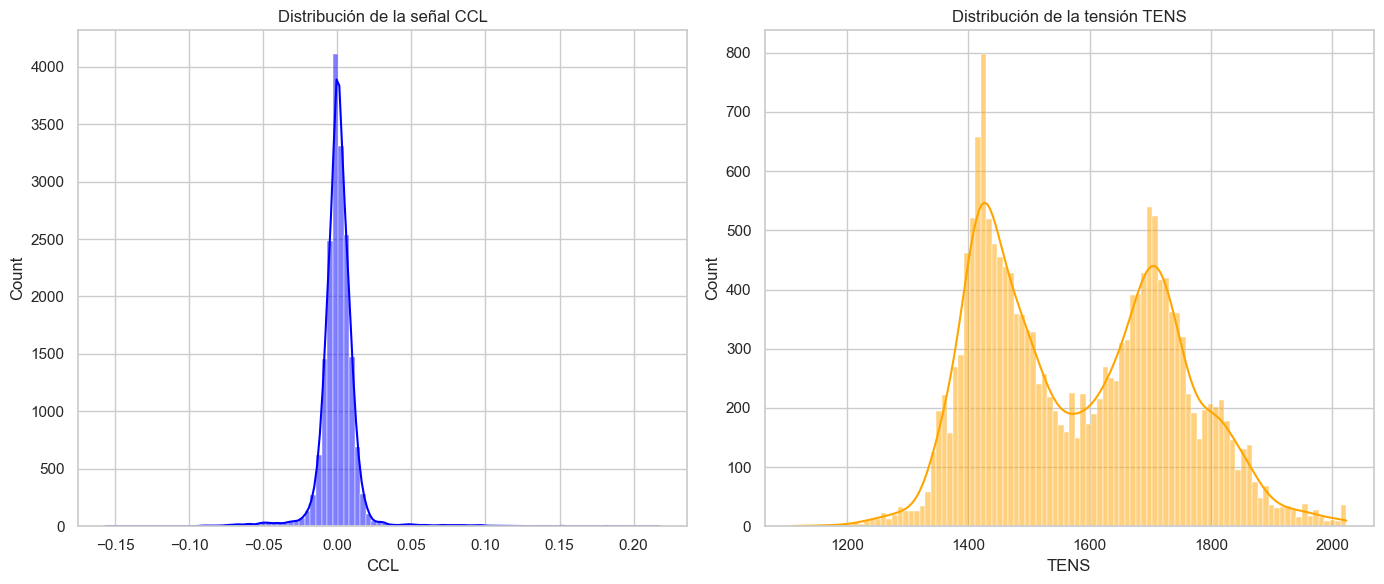

In [17]:
# Histogramas generales de CCL y TENS
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['CCL'], bins=100, kde=True, color='blue')
plt.title("Distribución de la señal CCL")

plt.subplot(1, 2, 2)
sns.histplot(df['TENS'], bins=100, kde=True, color='orange')
plt.title("Distribución de la tensión TENS")

plt.tight_layout()
plt.show()


### 📈 Celda 5.1 - Análisis de correlaciones entre variables numéricas

#### 🔗 Análisis de correlaciones numéricas

A continuación se muestra la matriz de correlación entre las variables numéricas del dataset. Esto permite detectar relaciones lineales fuertes o débiles entre `CCL`, `TENS` y `DEPT`.


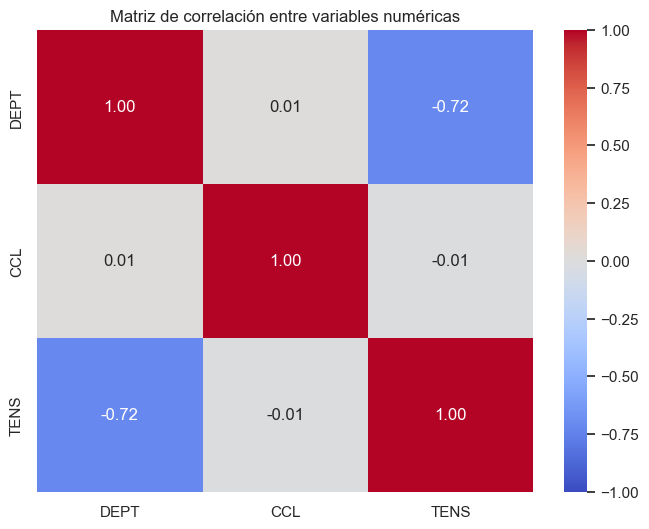

In [18]:
# Seleccionamos solo columnas numéricas para evitar errores
num_cols = df.select_dtypes(include=np.number)

# Calculamos la matriz de correlación
corr_matrix = num_cols.corr()

# Graficamos la matriz
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


## 🛠 Celda 6 - Análisis por dirección (sentido)

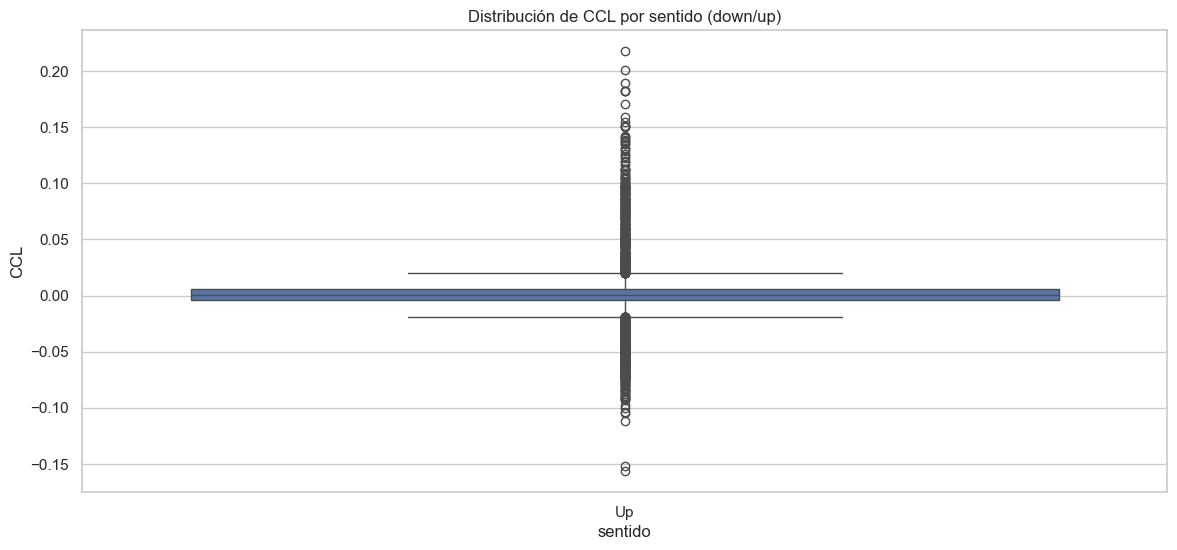

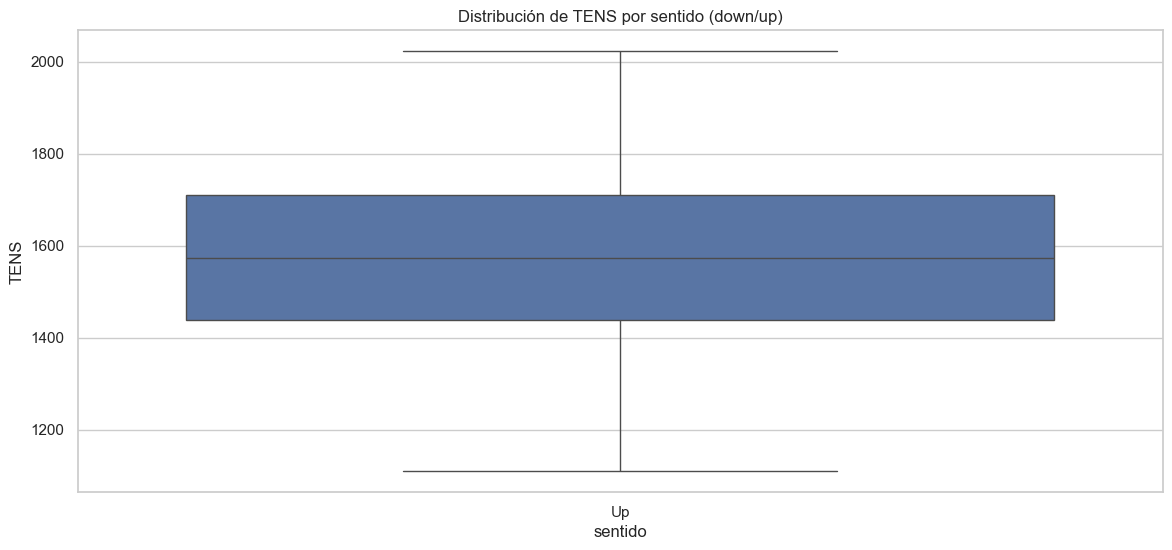

In [19]:
# Comparamos CCL y TENS según 'sentido' (down vs up)
plt.figure(figsize=(14, 6))

sns.boxplot(data=df, x="sentido", y="CCL")
plt.title("Distribución de CCL por sentido (down/up)")
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="sentido", y="TENS")
plt.title("Distribución de TENS por sentido (down/up)")
plt.show()


## 🧪 Celda 7 - Exploración por pozo y etapa

C:\Users\FSONZOGNI\AppData\Local\Temp\ipykernel_26340\2184426995.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.tight_layout()
c:\Users\FSONZOGNI\AppData\Local\anaconda3\envs\CCL_Anomalias\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


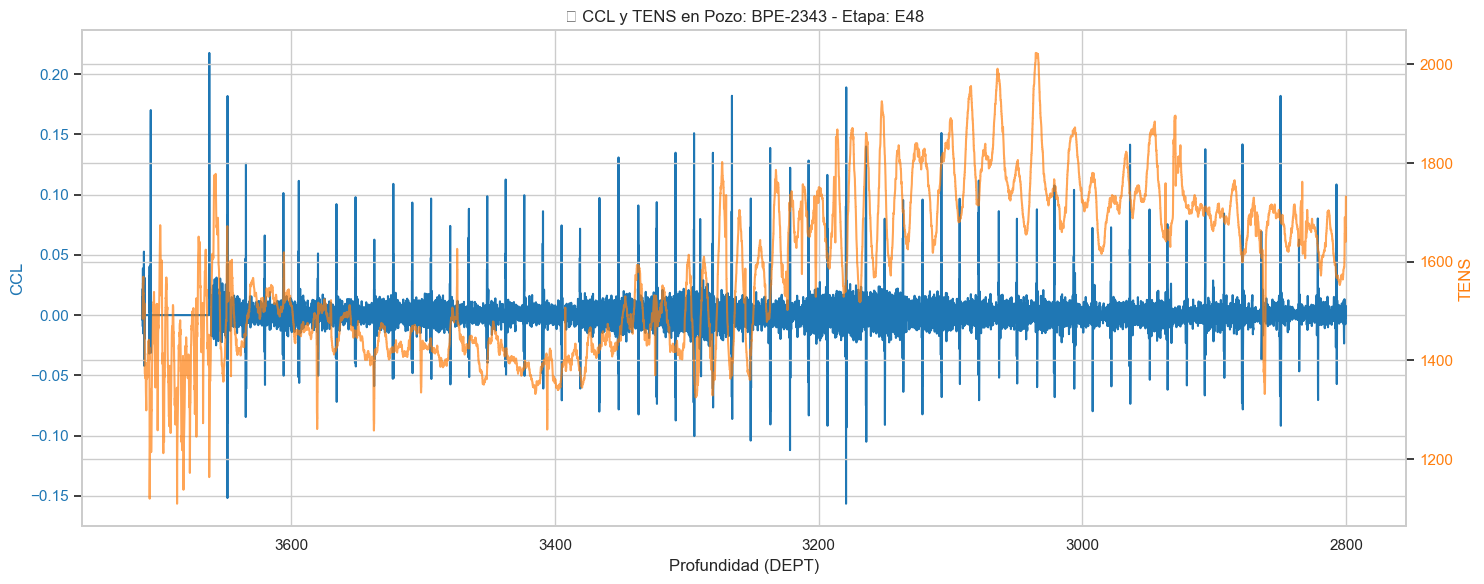

In [20]:
# Vista por pozo y etapa con ejes Y independientes para CCL y TENS
pozo_sample = df["pozo"].unique()[0]
etapa_sample = df[df["pozo"] == pozo_sample]["etapa"].unique()[0]

df_sample = df[(df["pozo"] == pozo_sample) & (df["etapa"] == etapa_sample)]

fig, ax1 = plt.subplots(figsize=(15, 6))

# Primer eje Y para CCL
color_ccl = "tab:blue"
ax1.set_xlabel("Profundidad (DEPT)")
ax1.set_ylabel("CCL", color=color_ccl)
ax1.plot(df_sample["DEPT"], df_sample["CCL"], label="CCL", color=color_ccl)
ax1.tick_params(axis='y', labelcolor=color_ccl)
ax1.invert_xaxis()

# Segundo eje Y para TENS
ax2 = ax1.twinx()
color_tens = "tab:orange"
ax2.set_ylabel("TENS", color=color_tens)
ax2.plot(df_sample["DEPT"], df_sample["TENS"], label="TENS", color=color_tens, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_tens)

# Título y leyenda combinada
plt.title(f"📈 CCL y TENS en Pozo: {pozo_sample} - Etapa: {etapa_sample}")
fig.tight_layout()
plt.grid(True)
plt.show()


## ⚡ Celda 8 - AutoEDA con Sweetviz (opcional, pesado)

In [21]:
# Generar reporte de Sweetviz
report = sweetviz.analyze(df)
report.show_html("sweetviz_report.html")


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## 📋 Celda 9 - AutoEDA con YData Profiling (antes Pandas Profiling)

In [22]:
# Puede ser pesado para muchos datos. Recomendado en subset.
profile = ProfileReport(df.sample(10000) if len(df) > 10000 else df, title="Reporte de AutoEDA", explorative=True)
profile.to_file("profile_report.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 271.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## ✅ Celda 10 - Conclusiones iniciales (Markdown)

## 🧠 Conclusiones Iniciales

- Se visualizó una ...
- La tensión TENS podría ...
- Se recomienda seguir explorando correlaciones ...
- Este análisis visual servirá de base para crear ...
